# Website Traffic Analysis


Importing Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import networkx as nx

from collections import Counter

In [33]:
sns.set_style("whitegrid")

Load Dataset

In [34]:
df = pd.read_csv("website_traffic.csv")

 DATA OVERVIEW

In [35]:
print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nCOLUMNS")
print(df.columns)

print("\nSHAPE")
print(df.shape)


FIRST 5 ROWS
   event        date       country      city  \
0  click  2021-08-21  Saudi Arabia    Jeddah   
1  click  2021-08-21  Saudi Arabia    Jeddah   
2  click  2021-08-21         India  Ludhiana   
3  click  2021-08-21        France   Unknown   
4  click  2021-08-21      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a-34965c3b0cc2  
3  BRUM72003904  35573248-4e49-47c7-af80-08a960fa74c

DATA CLEANING

In [36]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Extract time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
year       0
month      0
day        0
dtype: int64


CREATE SYNTHETIC USER IDs

In [37]:
df['user_id'] = (
    df['country'].astype(str)
    + "_"
    + df['city'].astype(str)
).factorize()[0]

CREATE SYNTHETIC SESSION IDs

In [38]:
df['session_id'] = (
    df['user_id'].astype(str)
    + "_"
    + df['date'].dt.date.astype(str)
)

CREATE SYNTHETIC PAGES

In [39]:
def assign_page(event):

    if event == 'click':
        return 'Landing Page'

    elif event == 'preview':
        return 'Track Detail Page'

    elif event == 'download':
        return 'Download Page'

    return 'Other'

df['page'] = df['event'].apply(assign_page)

CREATE SESSION DURATIONS

In [40]:
def session_duration(event):

    if event == 'click':
        return np.random.randint(5, 30)

    elif event == 'preview':
        return np.random.randint(30, 180)

    elif event == 'download':
        return np.random.randint(10, 60)

    return np.random.randint(5, 20)

df['duration'] = df['event'].apply(session_duration)

Create Referral Sources Using Country Logic

In [41]:
def traffic_source(country):

    if country in ['United States', 'United Kingdom']:
        return 'Organic Search'

    elif country in ['India', 'Pakistan']:
        return 'Social Media'

    return 'Direct'

df['referral_source'] = df['country'].apply(traffic_source)

 CREATE DEVICE TYPES

In [42]:
def device_type(country):

    if country in ['India', 'Pakistan']:
        return 'Mobile'

    return np.random.choice(
        ['Desktop', 'Tablet']
    )

df['device'] = df['country'].apply(device_type)

USER JOURNEY CREATION

In [43]:
df = df.sort_values(['session_id', 'date'])

df['next_page'] = df.groupby(
    'session_id'
)['page'].shift(-1)


 SAVE CLEANED DATA

In [44]:

df.to_csv(
    "cleaned_website_traffic.csv",
    index=False
)

print("\nCLEANED DATA SAVED")


CLEANED DATA SAVED


 BASIC METRICS

In [45]:

print("\n============================")
print("WEBSITE TRAFFIC METRICS")
print("============================")

# Total users
total_users = df['user_id'].nunique()

print("\nTotal Users:", total_users)

# Total sessions
total_sessions = df['session_id'].nunique()

print("Total Sessions:", total_sessions)

# Total events
total_events = len(df)

print("Total Events:", total_events)

# Total artists
total_artists = df['artist'].nunique()

print("Total Artists:", total_artists)

# Total tracks
total_tracks = df['track'].nunique()

print("Total Tracks:", total_tracks)


WEBSITE TRAFFIC METRICS

Total Users: 12155
Total Sessions: 25782
Total Events: 116257
Total Artists: 590
Total Tracks: 693


 BOUNCE RATE

In [46]:

session_counts = df.groupby(
    'session_id'
)['page'].count()

bounces = session_counts[
    session_counts == 1
].count()

bounce_rate = (
    bounces / total_sessions
) * 100

print("\nBounce Rate: {:.2f}%".format(
    bounce_rate
))


Bounce Rate: 33.77%


AVERAGE SESSION DURATION

In [47]:

avg_session_duration = df.groupby(
    'session_id'
)['duration'].sum().mean()

print(
    "\nAverage Session Duration:",
    round(avg_session_duration, 2),
    "seconds"
)



Average Session Duration: 119.64 seconds


Event Analysis

In [48]:

print("\nEVENT DISTRIBUTION")

event_counts = df['event'].value_counts()

print(event_counts)


EVENT DISTRIBUTION
event
pageview    69013
click       30537
preview     16707
Name: count, dtype: int64


Top Artist

In [49]:
print("\nTOP ARTISTS")

top_artists = df['artist'].value_counts().head(10)

print(top_artists)


TOP ARTISTS
artist
Tesher                                                          8288
Anne-Marie                                                      4028
Tundra Beats                                                    3950
Roddy Ricch                                                     3103
Olivia Rodrigo                                                  3025
Surf Mesa, Emilee                                               2947
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2672
PinkPantheress                                                  2444
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


TOP ALBUMS

In [50]:
print("\nTOP ALBUMS")

top_albums = df['album'].value_counts().head(10)

print(top_albums)


TOP ALBUMS
album
Jalebi Baby                             8288
Beautiful                               4028
Beautiful Day                           3950
Late At Night                           3059
ily (i love you baby) (feat. Emilee)    2947
The Massacre                            2870
SOUR                                    2866
Calabria (feat. Lujavo & Nito-Onna)     2865
So Pretty                               2827
Summer Of Love                          2108
Name: count, dtype: int64


REFERRAL SOURCE ANALYSIS

In [51]:
print("\nREFERRAL SOURCES")

referral_counts = df[
    'referral_source'
].value_counts()

print(referral_counts)


REFERRAL SOURCES
referral_source
Direct            66024
Organic Search    28957
Social Media      21276
Name: count, dtype: int64


COUNTRY ANALYSIS

In [52]:
print("\nTOP COUNTRIES")

top_countries = df[
    'country'
].value_counts().head(10)

print(top_countries)


TOP COUNTRIES
country
United States     23868
India             18688
France            10547
Saudi Arabia       7464
United Kingdom     5089
Germany            3984
Pakistan           2588
Canada             2419
Turkey             2380
Iraq               2375
Name: count, dtype: int64


CITY ANALYSIS

In [53]:
print("\nTOP CITIES")

top_cities = df[
    'city'
].value_counts().head(10)

print(top_cities)



TOP CITIES
city
Unknown      8290
Jeddah       2381
Riyadh       2172
Hyderabad    1088
Dammam        981
Delhi         884
Jaipur        849
Lucknow       837
Ahmedabad     808
Pune          799
Name: count, dtype: int64


LANDING PAGES

In [54]:
landing_pages = (
    df.sort_values('date')
    .groupby('session_id')
    .first()['page']
)

print("\nTOP LANDING PAGES")

print(
    landing_pages.value_counts()
)



TOP LANDING PAGES
page
Other                17929
Landing Page          5966
Track Detail Page     1887
Name: count, dtype: int64


EXIT PAGES

In [55]:
exit_pages = (
    df.sort_values('date')
    .groupby('session_id')
    .last()['page']
)

print("\nTOP EXIT PAGES")

print(
    exit_pages.value_counts()
)



TOP EXIT PAGES
page
Other                17726
Landing Page          6103
Track Detail Page     1953
Name: count, dtype: int64


USER FLOW ANALYSIS

In [56]:

journeys = df.groupby(
    ['page', 'next_page']
).size().reset_index(name='count')

print("\nUSER JOURNEYS")

print(journeys.head())



USER JOURNEYS
           page          next_page  count
0  Landing Page       Landing Page  17262
1  Landing Page              Other   8585
2  Landing Page  Track Detail Page   4489
3         Other              Other  43442
4         Other  Track Detail Page     48


 DAILY TRAFFIC ANALYSIS

In [57]:

daily_traffic = df.groupby(
    'date'
).size()


DEVICE ANALYSIS

In [58]:
device_analysis = pd.crosstab(
    df['device'],
    df['event']
)

print("\nDEVICE ANALYSIS")

print(device_analysis)


DEVICE ANALYSIS
event    click  pageview  preview
device                           
Desktop  12202     28402     6735
Mobile    6101     11914     3261
Tablet   12234     28697     6711


TOP TRACKS ANALYSIS


In [59]:
top_tracks = df['track'].value_counts().head(10)

print(top_tracks)

track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3950
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2947
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2827
Candy Shop                               2390
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


CONVERSION FUNNEL

In [60]:
print("\nCONVERSION FUNNEL")

funnel = df['event'].value_counts()

print(funnel)


CONVERSION FUNNEL
event
pageview    69013
click       30537
preview     16707
Name: count, dtype: int64


 VISUALIZATIONS

1 — EVENT DISTRIBUTION

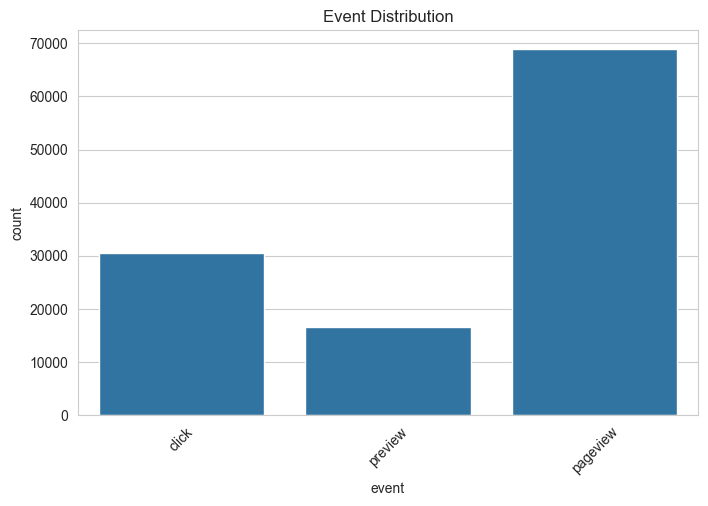

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='event',
    data=df
)

plt.title("Event Distribution")

plt.xticks(rotation=45)

plt.show()


 2 — TOP ARTISTS

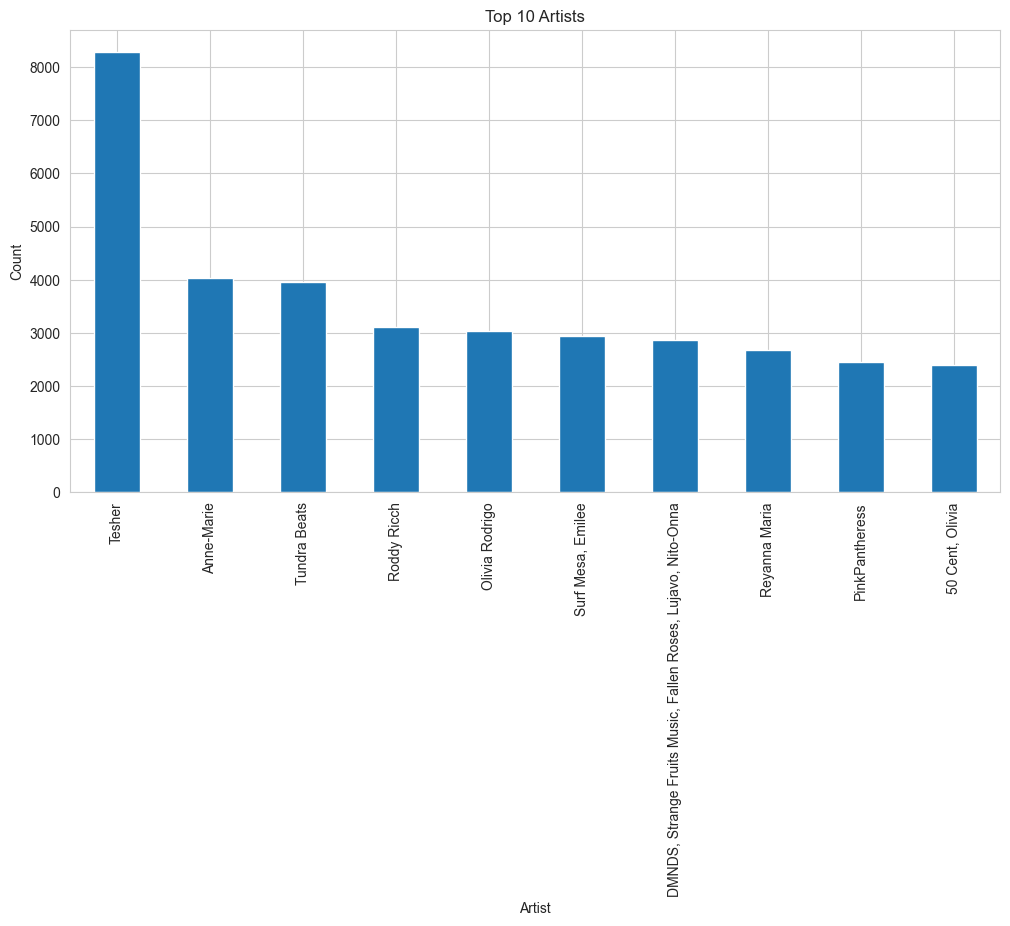

In [62]:

plt.figure(figsize=(12,6))

top_artists.plot(kind='bar')

plt.title("Top 10 Artists")

plt.xlabel("Artist")

plt.ylabel("Count")

plt.show()

 3 — TOP TRACKS

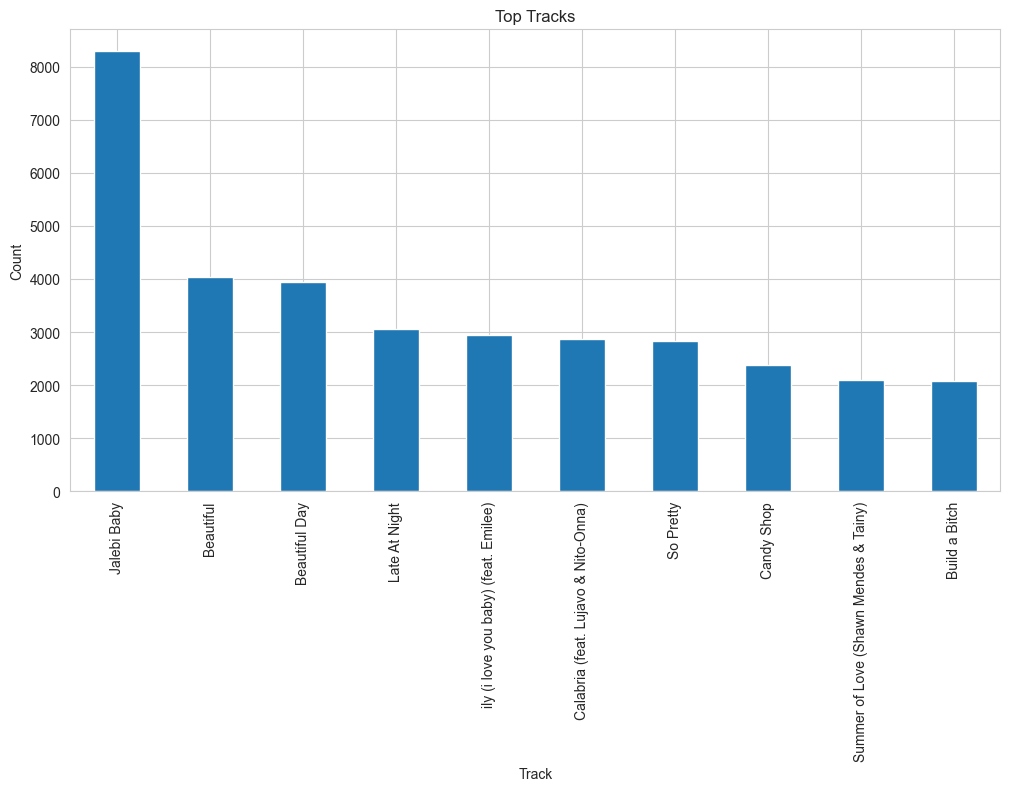

In [63]:
plt.figure(figsize=(12,6))

top_tracks.plot(kind='bar')

plt.title("Top Tracks")

plt.xlabel("Track")

plt.ylabel("Count")

plt.show()

4 — COUNTRY TRAFFIC

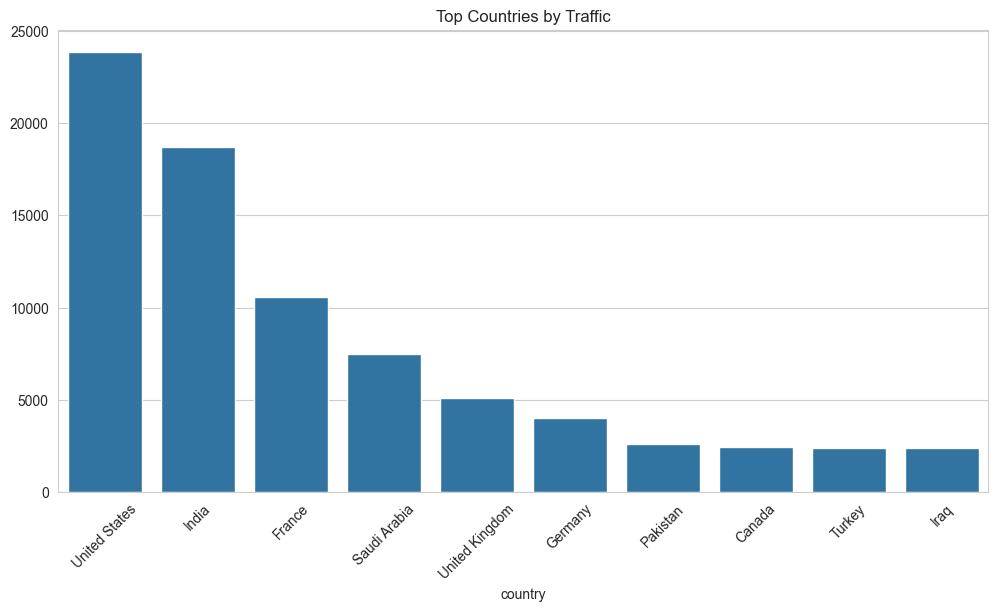

In [64]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top Countries by Traffic")

plt.xticks(rotation=45)

plt.show()

5 — DAILY TRAFFIC TREND

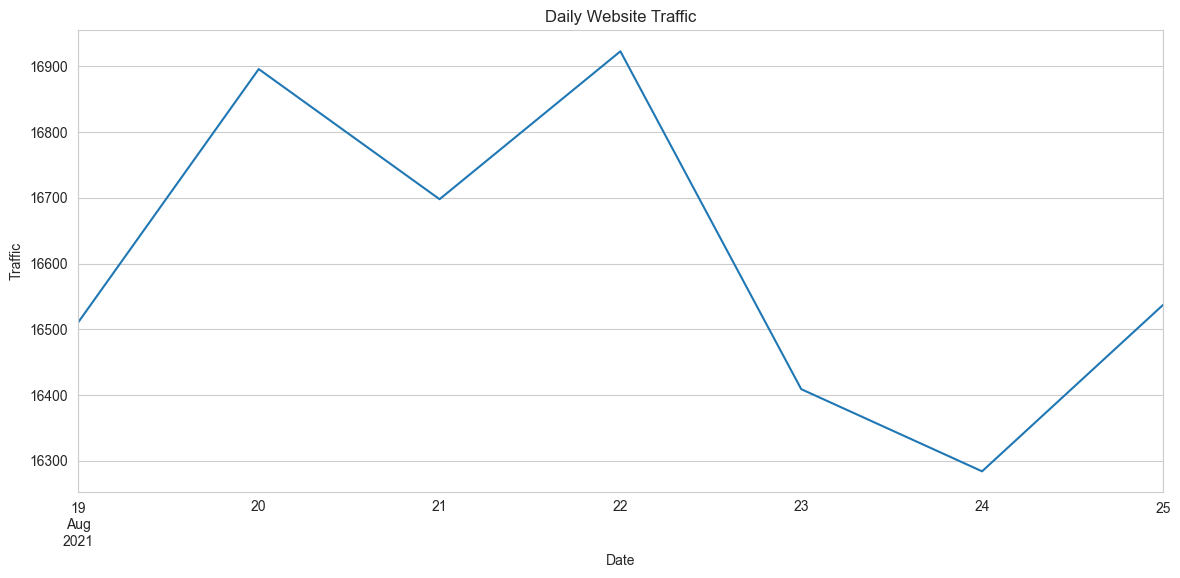

In [65]:

plt.figure(figsize=(14,6))

daily_traffic.plot()

plt.title("Daily Website Traffic")

plt.xlabel("Date")

plt.ylabel("Traffic")

plt.show()

6 — BOUNCE RATE PIE CHART

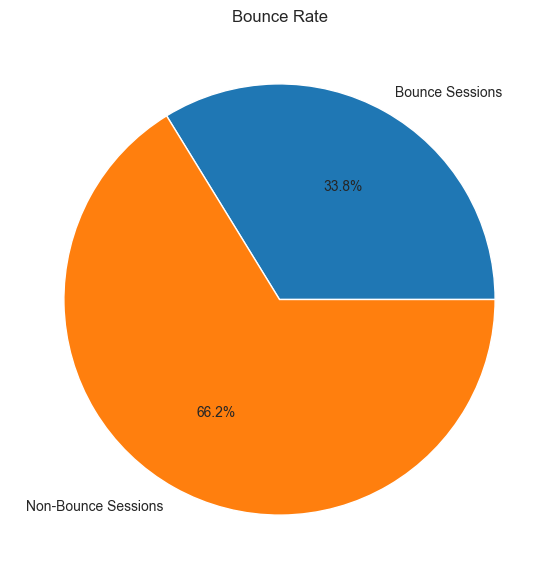

In [66]:
plt.figure(figsize=(7,7))

labels = [
    'Bounce Sessions',
    'Non-Bounce Sessions'
]

sizes = [
    bounces,
    total_sessions - bounces
]

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Bounce Rate")

plt.show()

 REFERRAL SOURCES

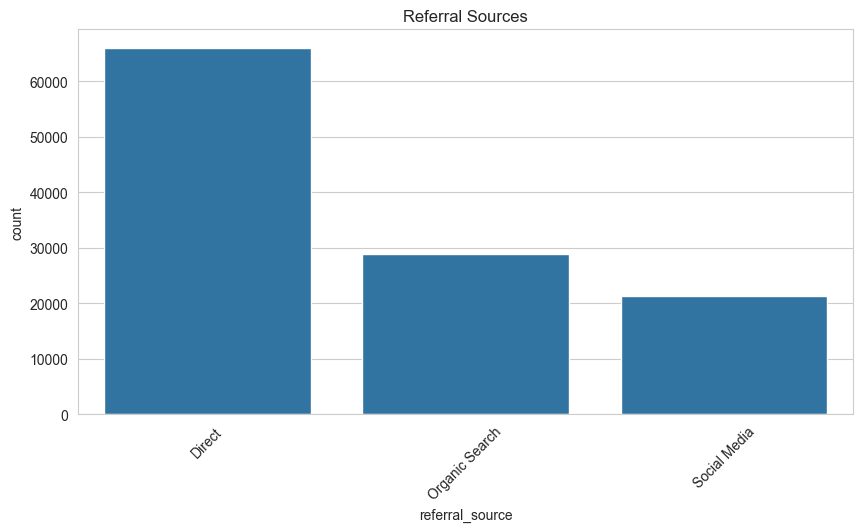

In [67]:

plt.figure(figsize=(10,5))

sns.countplot(
    x='referral_source',
    data=df
)

plt.title("Referral Sources")

plt.xticks(rotation=45)

plt.show()

DEVICE ANALYSIS

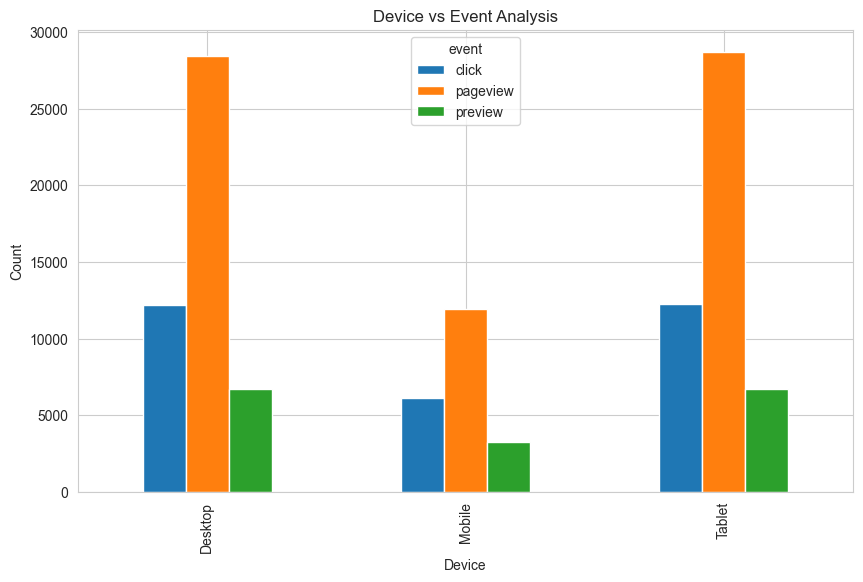

In [68]:

device_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Device vs Event Analysis")

plt.xlabel("Device")

plt.ylabel("Count")

plt.show()

 CONVERSION FUNNEL

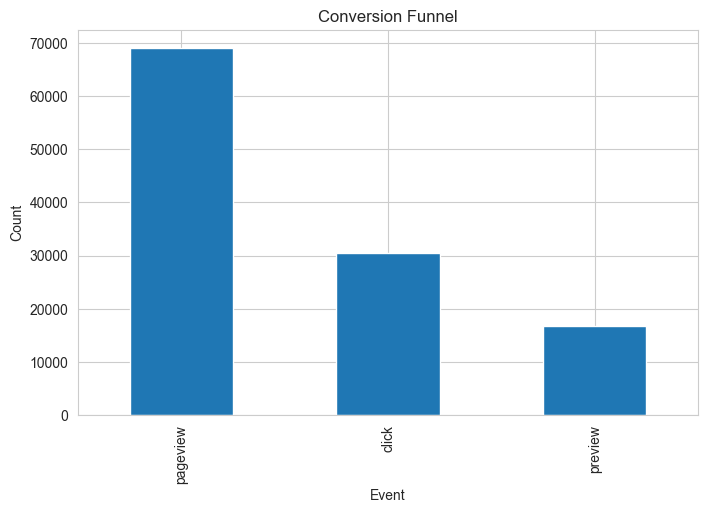

In [69]:
plt.figure(figsize=(8,5))

funnel.plot(kind='bar')

plt.title("Conversion Funnel")

plt.xlabel("Event")

plt.ylabel("Count")

plt.show()

10 — HEATMAP

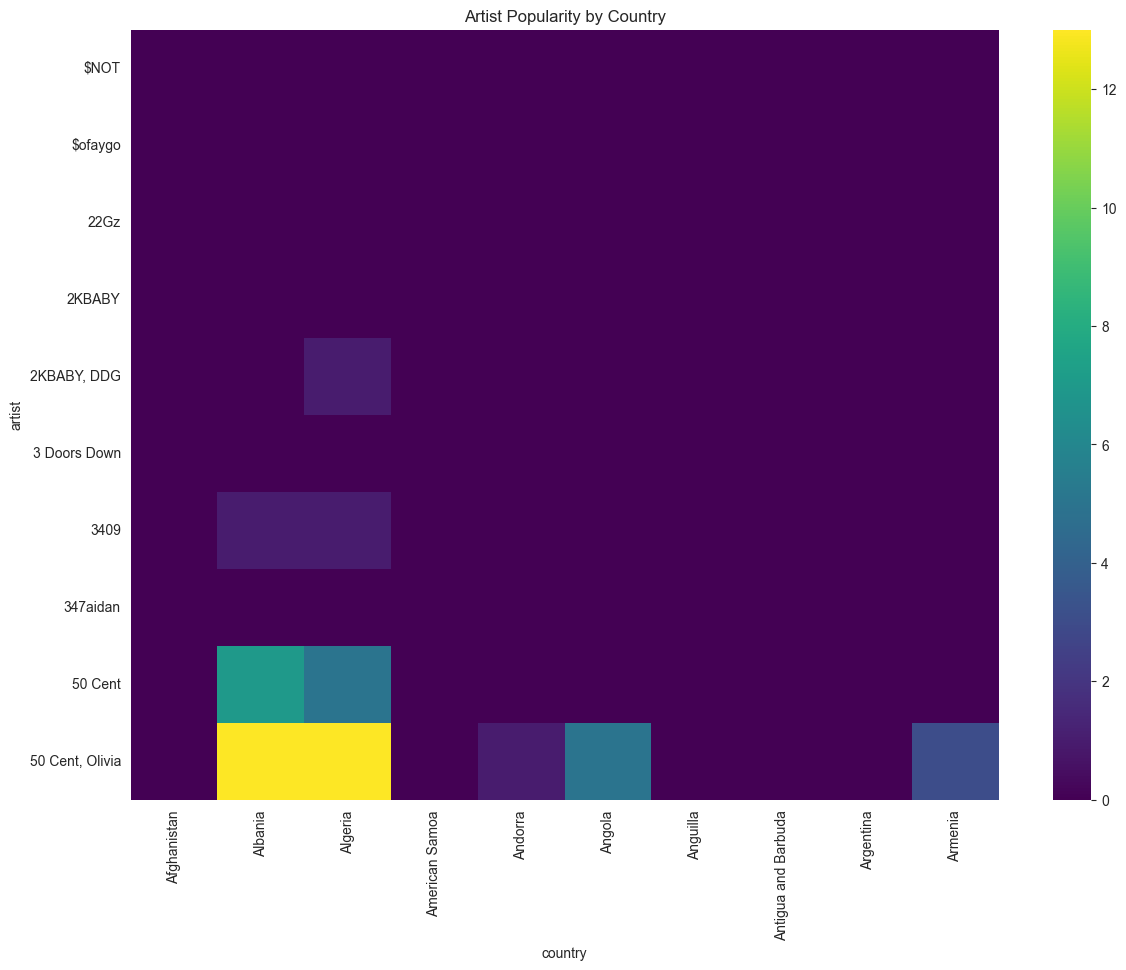

In [70]:

artist_country = pd.crosstab(
    df['artist'],
    df['country']
)

plt.figure(figsize=(14,10))

sns.heatmap(
    artist_country.iloc[:10, :10],
    cmap='viridis'
)

plt.title("Artist Popularity by Country")

plt.show()


 11 — USER FLOW GRAPH

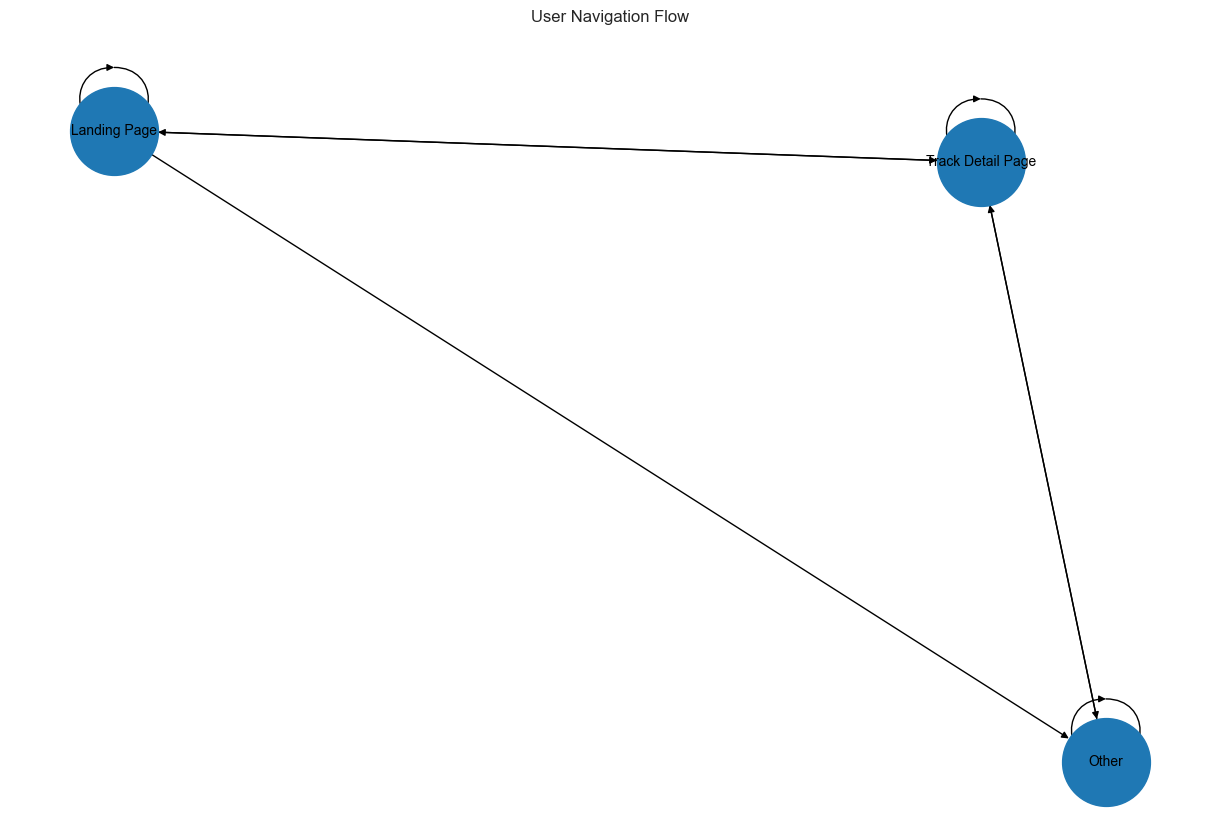

In [71]:
G = nx.from_pandas_edgelist(
    journeys,
    source='page',
    target='next_page',
    edge_attr='count',
    create_using=nx.DiGraph()
)

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=4000,
    font_size=10
)

plt.title("User Navigation Flow")

plt.show()

 12 — SESSION DURATION DISTRIBUTION


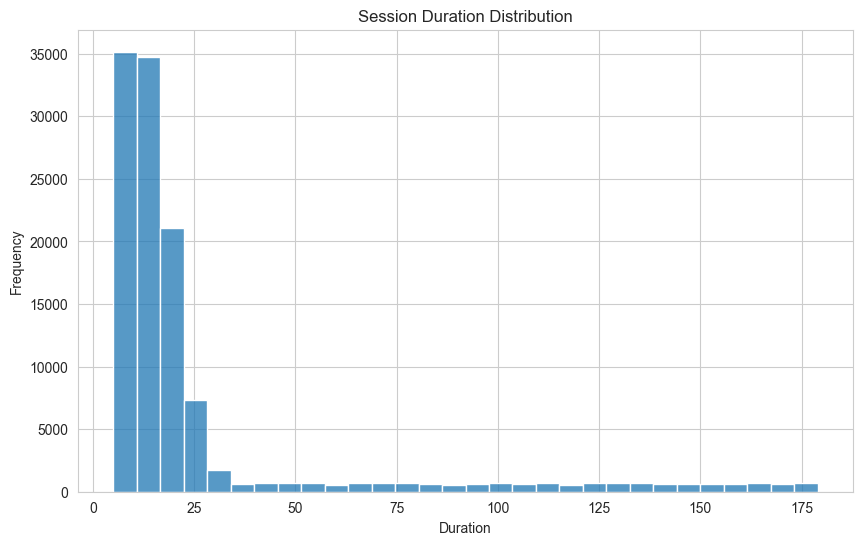

In [72]:

plt.figure(figsize=(10,6))

sns.histplot(
    df['duration'],
    bins=30
)

plt.title("Session Duration Distribution")

plt.xlabel("Duration")

plt.ylabel("Frequency")

plt.show()

13 — INTERACTIVE PLOTLY CHART

In [73]:
fig = px.bar(
    x=top_artists.index,
    y=top_artists.values,
    title="Top Artists"
)

fig.show()

 BUSINESS INSIGHTS

1. Most users interact through click events.

2. Certain artists and tracks generate
   significantly higher engagement.

3. Traffic is concentrated in a few countries
   and cities.

4. Mobile users generate a large portion
   of interactions.

5. Some referral sources perform better
   than others.

6. Download events are lower compared to
   click events, indicating conversion
   opportunities.

RECOMMENDATIONS

1. Improve high-performing landing pages.

2. Focus marketing campaigns on top
   performing countries.

3. Optimize mobile experience.

4. Improve conversion funnel from
   click → preview → download.

5. Promote trending artists and tracks
   more aggressively.

6. Invest more in high-performing
   referral channels.

7. Reduce bounce rate using better
   recommendations and CTA buttons.